In [22]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display



In [23]:
sample_size = 20
population_mean = 0.5
data = np.random.randn(sample_size) + population_mean

display("Data: ", data)



'Data: '

array([ 1.13767433,  1.15774173,  1.74425906, -0.77025644, -0.37582956,
       -0.55806668,  0.92095739,  1.07150152,  2.87503497,  0.1350073 ,
        1.09282252,  1.40897824, -0.48044071, -1.08564678,  0.81341301,
        0.76222575,  0.61995161,  2.60372508,  0.17719001, -0.36245308])

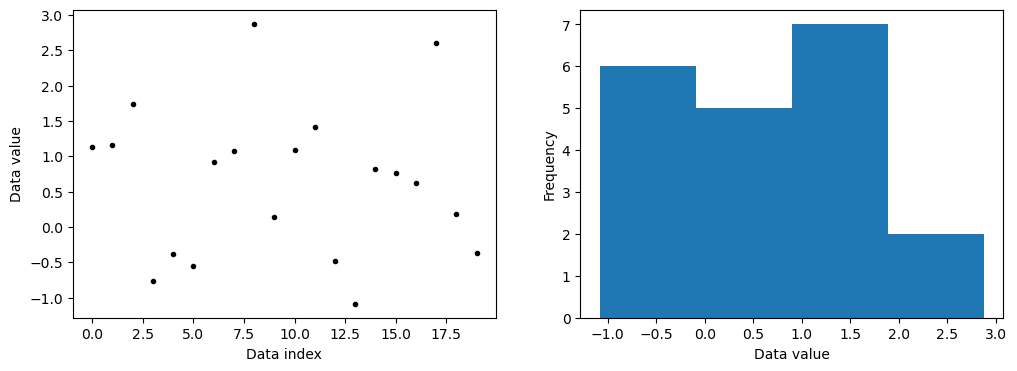

In [24]:
fig, ax =plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(data, 'k.')
ax[0].set_xlabel('Data index')
ax[0].set_ylabel('Data value')
ax[1].hist(data, bins='fd')
ax[1].set_xlabel('Data value')
ax[1].set_ylabel('Frequency')
plt.show()


't-value and p-value:  2.6868766995732694 0.007298220520385756'

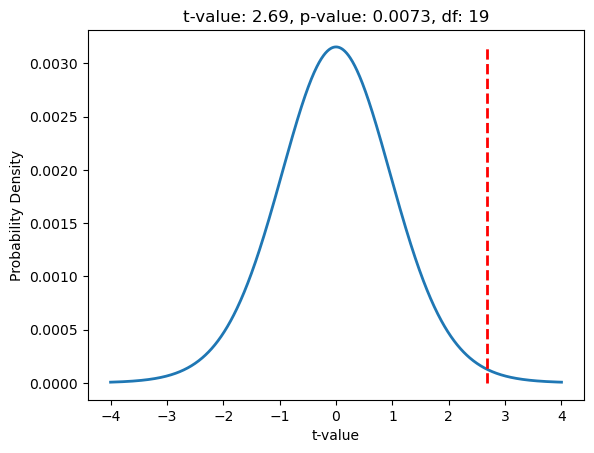

In [25]:
# manual t-test

from scipy import stats


H0 = 0 # null hypothesis, the population mean is 0
df = sample_size - 1

# Calculating the t-statistic
numerator = np.mean(data) - H0
denominator = np.std(data, ddof=1) / np.sqrt(sample_size)

t_value = numerator / denominator

p_value = 1 - stats.t.cdf(t_value, df=df)

display(f't-value and p-value:  {t_value} {p_value}')


x = np.linspace(-4, 4, 1000)
tdist = stats.t.pdf(x, df)

#display(f"x values: {x}")
discrete_diff = np.diff(x)
#display(f"Discrete differences: {discrete_diff}")
tdist = stats.t.pdf(x, df) * np.mean(discrete_diff)
#display(f"t-distribution values: {tdist}")
plt.plot(x, tdist, label='t-distribution', linewidth=2)
plt.plot([t_value, t_value], [0, max(tdist)], 'r--', label='t-value', linewidth=2)
plt.xlabel('t-value')
plt.ylabel('Probability Density')
plt.title(f't-value: {t_value:.2f}, p-value: {p_value:.4f}, df: {df}')
plt.show()



In [26]:
t, p = stats.ttest_1samp(data, popmean=H0)
display(f't-value and p-value from scipy:  {t} {p}')

't-value and p-value from scipy:  2.68687669957327 0.014596441040771494'